In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import cv2
import re

In [49]:
test_df = pd.read_csv('new_test/new_test.csv')
print(test_df.head())
print(test_df.columns)

   0  1  2  3  4  5  6  7  8  9  ...  4086  4087  4088  4089  4090  4091  \
0  0  0  4  0  0  0  0  0  0  0  ...     0     0     3     0     0     2   
1  0  0  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
2  0  0  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
3  0  0  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   
4  0  0  0  0  0  0  0  0  0  0  ...     0     0     0     0     0     0   

   4092  4093  4094  4095  
0     0     1     0     2  
1     0     0     0     0  
2     0     0     0     0  
3     0     0     0     0  
4     0     0     0     0  

[5 rows x 4096 columns]
Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '4086', '4087', '4088', '4089', '4090', '4091', '4092', '4093', '4094',
       '4095'],
      dtype='object', length=4096)


In [2]:
df = pd.read_csv('sample_submission.csv')
df

,Id,Category
0,1,3
1,2,48
2,3,16
3,4,59
4,5,28
...,...,...
49995,49996,60
49996,49997,33
49997,49998,38
49998,49999,28


In [3]:
image_jpg = os.listdir('Train/Train/')
image_jpg

['0',
 '1',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '2',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '3',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '4',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '5',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '6',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '7',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '8',
 '9']

In [4]:
image_jpg = sorted(os.listdir('Train/Train/'), key=lambda x: int(x))
print(image_jpg)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77']


In [5]:
X_train = []
y_train = []

for i in sorted(os.listdir('Train/Train/'), key=lambda x: int(x)):  
    class_path = f'Train/Train/{i}'
    class_label = int(i)
    for j in os.listdir(class_path):      
        try:
            image_path = f'{class_path}/{j}'
            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            if image is None:
                continue
            image = cv2.resize(image, (64, 64))
            image = image / 255.0
            image = image.reshape(64, 64, 1)
            
            X_train.append(image)
            y_train.append(class_label)
            
        except:
            continue

X_train = np.array(X_train)
y_train = np.array(y_train)

In [6]:
X_train

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [7]:
y_train

array([ 0,  0,  0, ..., 77, 77, 77], shape=(70060,))

In [8]:
from sklearn.utils import shuffle

In [9]:
X_train,y_train = shuffle(X_train,y_train,random_state=42)

In [10]:
X_train.shape

(70060, 64, 64, 1)

In [11]:
y_train.shape

(70060,)

In [12]:
from keras.utils import to_categorical

In [13]:
y_train = to_categorical(y_train,num_classes=78)

In [26]:
y_train.shape

(70060, 78)

In [36]:
from keras import Sequential
from keras.layers import Conv2D , MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam

In [63]:
86
# model = Sequential()
# model.add(Conv2D(filters=64, kernel_size=(5, 5), activation='relu', input_shape=(64, 64, 1)))
# model.add(MaxPooling2D(pool_size=(2, 2)))

# model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2)))

# model.add(Flatten())

# model.add(Dense(units=120, activation='relu'))
# model.add(Dense(units=64, activation='relu'))
# model.add(Dense(units=30, activation='relu'))
# model.add(Dense(units=78, activation='softmax'))

C:\Users\USER\Desktop\ML jupyter\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(78, activation='softmax'))

C:\Users\USER\Desktop\ML jupyter\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.compile(optimizer=Adam(learning_rate=0.0005),loss='categorical_crossentropy',metrics=['accuracy'])

In [46]:
model.fit(X_train,y_train,validation_split=0.30,epochs=30)

Epoch 1/30
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.1518 - loss: 3.4673 - val_accuracy: 0.5590 - val_loss: 1.8223
Epoch 2/30
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 55s 36ms/step - accuracy: 0.4425 - loss: 1.9355 - val_accuracy: 0.7767 - val_loss: 0.8089
Epoch 3/30
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.6037 - loss: 1.3271 - val_accuracy: 0.8502 - val_loss: 0.5632
Epoch 4/30
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.6787 - loss: 1.0519 - val_accuracy: 0.8685 - val_loss: 0.4771
Epoch 5/30
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.7325 - loss: 0.8711 - val_accuracy: 0.8626 - val_loss: 0.5016
Epoch 6/30
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.7724 - loss: 0.7418 - val_accuracy: 0.8903 - val_loss: 0.4023
Epoch 7/30
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.7953 - loss: 0.6607 - val_accuracy: 0.8907 - val_loss: 0.3989
Epoch 8/30
1533/1533 ━━━━━━━━━━━━━━━━━━━━ 55s 36ms/step - accuracy: 0.8160 -

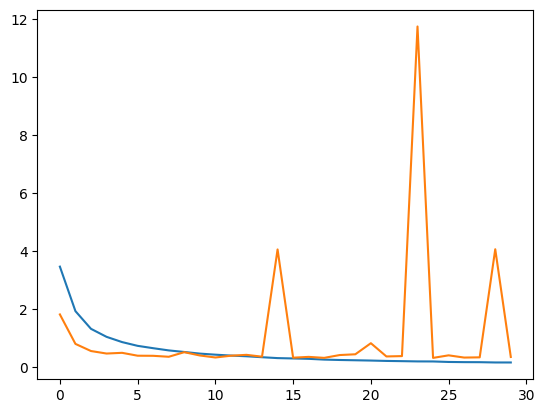

In [47]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [48]:
test_df = pd.read_csv('new_test/new_test.csv')
X_test = test_df.values
X_test = X_test.reshape(-1, 64, 64, 1)
X_test = X_test / 255.0

print("X_test shape:", X_test.shape)

X_test shape: (50000, 64, 64, 1)


In [49]:
y_pred = model.predict(X_test)
predicted_classes = np.argmax(y_pred, axis=1)
print(predicted_classes[:10])

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step
[68 33 38 29 38 52 13 38 76 38]


In [50]:
df_sub = pd.read_csv('sample_submission.csv')
print(df_sub.head())

   Id  Category
0   1         3
1   2        48
2   3        16
3   4        59
4   5        28


In [51]:
submission = df_sub.copy()
submission.iloc[:, 1] = predicted_classes
submission.to_csv("sub2.csv", index=False)